# Simplex-Tree Experiments on the Dry Bean (multiclass, MLP) Dataset

**Setup.** Dry Bean (UCI id 602; 13,611 rows, 16 numeric morphological features, 7 bean varieties -- BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER, SIRA). Scale features to [0,1], encode the class as an integer 0..6, RFE keeps the top 6 features. The explained network is a **fast feed-forward MLP** (softmax over 7 classes). Build a simplex-tree surrogate and find its non-convex leaves.

**Experiment 1.** Prune the non-convex simplices -> the surrogate's **generalisation coefficient goes up**.

**Experiment 2.** Follow LIME's target-reinforcing vector at a non-convex point vs a convex point. In the multiclass setting the **target** is the class the NN predicts at `x0`; the non-convexity fingerprint is that the NN's argmax **leaves** the target class and then **returns** to it along LIME's direction -- a non-monotonic path a linear LIME model cannot represent.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sys, os, warnings, time
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

# Make the SimplexTreeClassifier package importable.
here = os.getcwd()
for p in (os.path.join(here, '..', '..'), os.path.join(here, '..')):
    p = os.path.abspath(p)
    if p not in sys.path:
        sys.path.insert(0, p)
if here not in sys.path:
    sys.path.insert(0, here)

from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier
from in2D.tests.data_generators.generate_data_nd import create_simplex_vertices
from paper_experiments_utils import (
    FeatureGRU, FeatureMLP, train_nn, predict_classes, predict_proba,
    find_nonconvex_leaves, gate_nonconvex_depths, build_convex_surrogate,
    leaf_key_for_point, gen_coef,
    make_lime_explainer, lime_direction, push_along_lime)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


### 1. Load & preprocess (RFE pipeline)

In [2]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from ucimlrepo import fetch_ucirepo

# Dry Bean (UCI id 602): 13,611 rows, 16 numeric morphological features, 7 bean
# varieties. Numeric + clean -> a good multiclass boundary for the surrogate.
dry_bean = fetch_ucirepo(id=602)
X_df = dry_bean.data.features.select_dtypes(include=[np.number]).astype(np.float64)
all_feature_names = list(X_df.columns)
class_names = sorted(dry_bean.data.targets.iloc[:, 0].astype(str).unique())
class_to_int = {c: i for i, c in enumerate(class_names)}
y = dry_bean.data.targets.iloc[:, 0].astype(str).map(class_to_int).to_numpy()
print(f'Dry Bean shape: {X_df.shape}   classes ({len(class_names)}): {class_names}')
print('class counts:', dict(zip(*np.unique(y, return_counts=True))))

X_all = MinMaxScaler().fit_transform(X_df.values)

X_tr_all, X_te_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

N_SELECT = 6
rfe = RFE(LogisticRegression(max_iter=2000),
          n_features_to_select=min(N_SELECT, X_all.shape[1]))
rfe.fit(X_tr_all, y_train)
sel = rfe.support_
feature_names = [n for n, k in zip(all_feature_names, sel) if k]
X_train = X_tr_all[:, sel]
X_test  = X_te_all[:, sel]
n_features = int(sel.sum())

print(f'RFE-selected features ({n_features}): {feature_names}')
print(f'{X_all.shape[0]} samples | Train {len(X_train)} | Test {len(X_test)}')
print(f'Class counts (train): {dict(zip(*np.unique(y_train, return_counts=True)))}')

Dry Bean shape: (13611, 16)   classes (7): ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
class counts: {np.int64(0): np.int64(1322), np.int64(1): np.int64(522), np.int64(2): np.int64(1630), np.int64(3): np.int64(3546), np.int64(4): np.int64(1928), np.int64(5): np.int64(2027), np.int64(6): np.int64(2636)}


RFE-selected features (6): ['MinorAxisLength', 'EquivDiameter', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2']
13611 samples | Train 10888 | Test 2723
Class counts (train): {np.int64(0): np.int64(1057), np.int64(1): np.int64(418), np.int64(2): np.int64(1304), np.int64(3): np.int64(2837), np.int64(4): np.int64(1542), np.int64(5): np.int64(1621), np.int64(6): np.int64(2109)}


### 2. Train the MLP

Selected features -> feed-forward MLP (2 hidden layers of 64, ReLU) -> sigmoid (binary) or softmax (multiclass). This replaces the recurrent GRU with a plain MLP so training and surrogate evaluation run faster.

In [3]:
EPOCHS, BATCH_SIZE, LR = 200, 128, 0.01
n_classes = len(np.unique(y_train))
torch.manual_seed(42); np.random.seed(42)

nn_model = FeatureMLP(n_features, n_classes=n_classes, hidden=64).to(device)
# Load the saved network if models/drybean_mlp.pt exists; otherwise train it.
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'drybean_mlp.pt')
nn_loaded = os.path.exists(model_path)
if nn_loaded:
    ckpt = torch.load(model_path, map_location=device)
    nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
    if ckpt.get('loss_history') is not None:
        nn_model.loss_history = ckpt['loss_history']
    print(f'Loaded NN <- {model_path}')
else:
    t0 = time.time()
    train_nn(nn_model, X_train, y_train, X_test, y_test,
             epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, device=device)
    print(f'NN trained in {time.time()-t0:.1f}s')

nn_pred = lambda Z: predict_classes(nn_model, Z, device=device)
print(f'NN train acc: {accuracy_score(y_train, nn_pred(X_train)):.4f}')
print(f'NN test  acc: {accuracy_score(y_test,  nn_pred(X_test)):.4f}')


Loaded NN <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/drybean_mlp.pt


NN train acc: 0.9236
NN test  acc: 0.9148


In [4]:
# Save the trained network to the models/ folder (state_dict + the config
# needed to rebuild it). Reload later with:
#   ckpt = torch.load(model_path, map_location=device)
#   Net = FeatureMLP if ckpt['class'] == 'FeatureMLP' else FeatureGRU
#   nn_model = Net(**ckpt['config']).to(device)
#   nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'drybean_mlp.pt')
if globals().get('nn_loaded', False):
    print(f'NN loaded from cache; not re-saving ({model_path})')
else:
    os.makedirs(MODEL_DIR, exist_ok=True)
    torch.save({
        'class': type(nn_model).__name__,
        'state_dict': nn_model.state_dict(),
        'config': dict(d=n_features, n_classes=n_classes, hidden=64),
        'feature_names': globals().get('feature_names'),
        'class_names': globals().get('class_names'),
        'loss_history': getattr(nn_model, 'loss_history', None),
    }, model_path)
    print(f'Saved NN -> {model_path}')

NN loaded from cache; not re-saving (/home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/drybean_mlp.pt)


### Learning curve

Training loss as a function of the number of epochs (0-300). The model used by the rest of the notebook is the 200-epoch one above.

Loaded learning curve <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/drybean_curve.npy  (300 epochs)


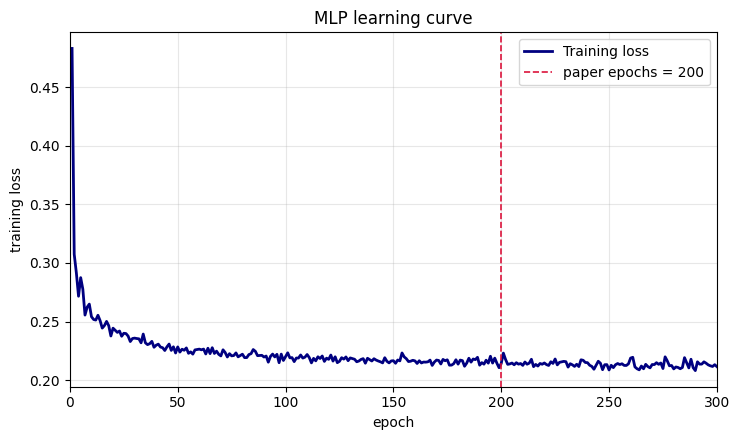

In [5]:
# Learning curve: load a cached loss history if present; else reuse the one
# already trained this session (if any) or train a fresh 300-epoch net. Cache it.
CURVE_EPOCHS = 300
MODEL_DIR = os.path.join(os.getcwd(), 'models')
curve_path = os.path.join(MODEL_DIR, 'drybean_curve.npy')
if os.path.exists(curve_path):
    loss_history = np.load(curve_path).tolist()
    print(f'Loaded learning curve <- {curve_path}  ({len(loss_history)} epochs)')
elif 'curve_model' in globals() and getattr(curve_model, 'loss_history', None):
    loss_history = list(curve_model.loss_history)   # cache what we already have
    os.makedirs(MODEL_DIR, exist_ok=True)
    np.save(curve_path, np.asarray(loss_history, dtype=np.float64))
    print(f'Saved current learning curve -> {curve_path}  ({len(loss_history)} epochs)')
else:
    torch.manual_seed(42); np.random.seed(42)
    curve_model = FeatureMLP(n_features, n_classes=n_classes, hidden=64).to(device)
    train_nn(curve_model, X_train, y_train, X_test, y_test,
             epochs=CURVE_EPOCHS, lr=0.01, batch_size=32, device=device)
    loss_history = curve_model.loss_history
    os.makedirs(MODEL_DIR, exist_ok=True)
    np.save(curve_path, np.asarray(loss_history, dtype=np.float64))
    print(f'Saved learning curve -> {curve_path}  ({len(loss_history)} epochs)')

epochs_axis = range(1, len(loss_history) + 1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(epochs_axis, loss_history, color='navy', lw=2,
        label='Training loss')
ax.axvline(200, color='crimson', ls='--', lw=1.2,
           label=f'paper epochs = 200')
ax.set_xlim(0, 300); ax.set_xlabel('epoch'); ax.set_ylabel('training loss')
ax.set_title('MLP learning curve')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 3. Build the simplex-tree surrogate

Fill `[0,1]^d` with random points labelled by the GRU, then add the real train points so every class is represented. The simplex tree (LinearSVC head, OvR-multiclass when n_classes>2) is trained on this fill set.

In [6]:
# Fill [0,1]^d with random points labelled by the GRU, then add the real train
# set so every class is represented. The surrogate fits this fill distribution.
N_FILL, C_PARAM = 5000, 10000
np.random.seed(42)
X_fill = np.random.uniform(0, 1, (N_FILL, n_features))
y_fill = nn_pred(X_fill)
X_fill = np.vstack([X_fill, X_train])
y_fill = np.concatenate([y_fill, nn_pred(X_train)])
print(f'Surrogate training points: {len(X_fill)}   '
      f'class counts: {dict(zip(*np.unique(y_fill, return_counts=True)))}')


Surrogate training points: 15888   class counts: {np.int64(0): np.int64(3316), np.int64(1): np.int64(533), np.int64(2): np.int64(1773), np.int64(3): np.int64(3120), np.int64(4): np.int64(2043), np.int64(5): np.int64(2696), np.int64(6): np.int64(2407)}


### Accuracy vs subdivision levels

Sweep the surrogate's `subdivision_levels` and plot the test agreement with the NN and the test accuracy against true labels.

subdivision_levels=3: leaves=   343  agreement-with-NN=0.8931  acc-vs-labels=0.8649


subdivision_levels=4: leaves=  2401  agreement-with-NN=0.8964  acc-vs-labels=0.8660


subdivision_levels=5: leaves= 16807  agreement-with-NN=0.9030  acc-vs-labels=0.8795

Highest agreement with NN at subdivision level 5 (= 0.9030)


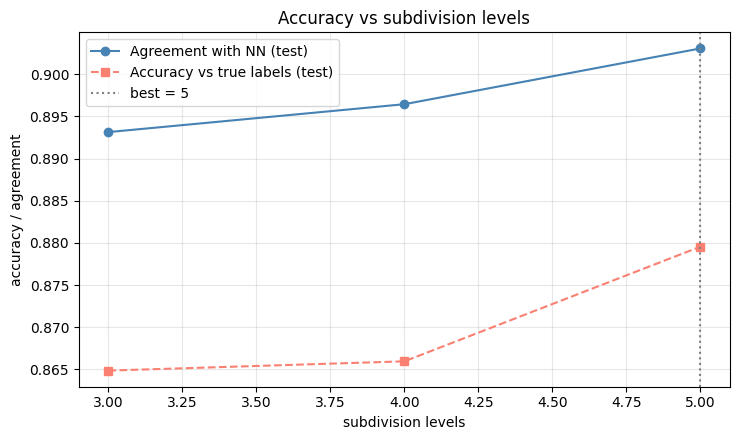

In [7]:
# Sweep subdivision_levels and report (a) surrogate-NN agreement on the test
# set, (b) surrogate accuracy on the true labels. In d=6 dims the tree has
# (d+1)**L = 7**L leaves, so we sweep a smaller range than the 2-4D notebooks.
sub_levels = [3, 4, 5]
agree_with_nn, acc_vs_labels = [], []
y_nn_te = nn_pred(X_test)
for L in sub_levels:
    m = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=L)
    m.fit(X_fill, y_fill)
    agree_with_nn.append(accuracy_score(y_nn_te, m.predict(X_test)))
    acc_vs_labels.append(accuracy_score(y_test, m.predict(X_test)))
    print(f'subdivision_levels={L}: leaves={len(m.leaf_simplexes):6d}  '
          f'agreement-with-NN={agree_with_nn[-1]:.4f}  '
          f'acc-vs-labels={acc_vs_labels[-1]:.4f}')

best_i = int(np.argmax(agree_with_nn))
print(f'\nHighest agreement with NN at subdivision level {sub_levels[best_i]} '
      f'(= {agree_with_nn[best_i]:.4f})')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sub_levels, agree_with_nn, 'o-', color='steelblue',
        label='Agreement with NN (test)')
ax.plot(sub_levels, acc_vs_labels, 's--', color='salmon',
        label='Accuracy vs true labels (test)')
ax.axvline(sub_levels[best_i], color='gray', ls=':',
           label=f'best = {sub_levels[best_i]}')
ax.set_xlabel('subdivision levels')
ax.set_ylabel('accuracy / agreement')
ax.set_title('Accuracy vs subdivision levels')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Initial surrogate at subdivision_levels = 5

Subdivision levels chosen to give a deep enough tree (7**5 = 16,807 leaves in 6D) that the surrogate starts to **overfit the fill points** -- exactly the regime where pruning the non-convex leaves should help.

In [8]:
import pickle
SUBDIVISION_LEVELS = 5
# Load the fitted surrogate (before removal) from disk if present; else fit and save it.
STC_PATH = os.path.join(os.getcwd(), 'models', 'drybean_stc.pkl')
if os.path.exists(STC_PATH):
    with open(STC_PATH, 'rb') as f:
        stc = pickle.load(f)
    print(f'Loaded stc <- {STC_PATH}')
else:
    stc = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)
    stc.fit(X_fill, y_fill)
    os.makedirs(os.path.dirname(STC_PATH), exist_ok=True)
    with open(STC_PATH, 'wb') as f:
        pickle.dump(stc, f)
    print(f'Saved stc -> {STC_PATH}')

print(f'Surrogate leaves: {len(stc.leaf_simplexes)}')
print(f'Agreement (fill) = {accuracy_score(y_fill, stc.predict(X_fill)):.4f}')
print(f'Agreement (test) = {accuracy_score(nn_pred(X_test), stc.predict(X_test)):.4f}')

Loaded stc <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/drybean_stc.pkl
Surrogate leaves: 16807


Agreement (fill) = 0.9502


Agreement (test) = 0.9030


### 4. Find non-convex regions

A leaf is **non-convex** if the boundary bends the wrong way versus any neighbour for ANY of the OvR hyperplanes. `epsilon` controls strictness (smaller = only severe curvature).

In [9]:
EPSILON = 0.05                 # sampling fraction along the boundary (check_convexity)
# The sign test alone flags almost every boundary-crossing leaf (a near-flat bend's
# side is basically noise). NONCONVEX_KEEP_FRAC is a DATA-dependent magnitude gate:
# keep only the deepest fraction of the flagged bends, so a convex MAJORITY remains.
# It adapts per dataset (cutoff = quantile of the observed depths), so nothing is
# hard-coded to this notebook's scale.
NONCONVEX_KEEP_FRAC = 0.25
crossing = stc.identify_crossing_simplices()
# Run the (expensive) detection ONCE, then apply the cheap magnitude gate.
depths_all = find_nonconvex_leaves(stc, epsilon=EPSILON)                       # ungated (sign test only)
depths     = gate_nonconvex_depths(depths_all, keep_frac=NONCONVEX_KEEP_FRAC)  # deepest-bend gate (~free)
print(f'Boundary-crossing simplices : {len(crossing)}')
print(f'Flagged by sign test        : {len(depths_all)}  '
      f'({len(depths_all) / max(len(stc.leaf_simplexes),1):.0%} of leaves)  <- too loose')
print(f'Non-convex simplices        : {len(depths)}  '
      f'({len(depths) / max(len(stc.leaf_simplexes),1):.0%} of leaves, '
      f'epsilon={EPSILON}, keep_frac={NONCONVEX_KEEP_FRAC})')

nonconvex_keys = set(depths.keys())
test_in_nc = np.array([leaf_key_for_point(stc, x) in nonconvex_keys for x in X_test])
print(f'Test points inside a non-convex region: {test_in_nc.sum()} / {len(X_test)}')


Boundary-crossing simplices : 16701
Flagged by sign test        : 16701  (99% of leaves)  <- too loose
Non-convex simplices        : 4176  (25% of leaves, epsilon=0.05, keep_frac=0.25)


Test points inside a non-convex region: 646 / 2723


## Experiment 1 -- Non-convex removal reduces overfitting

The surrogate copies the GRU from the fill points; with too many leaves it **overfits**. We remove the non-convex simplices (deepest bend first, up to 25% of leaves) and measure the **generalisation coefficient**

$$\text{gen\_coef} = \frac{\text{test accuracy}}{\text{train accuracy}}\quad(\text{higher = less overfitting}).$$

In [10]:
# Remove non-convex leaves -- deepest bend first, up to 25% of the initial
# leaf count (total budget). Refits after each pass.
# Load the pruned surrogate (after removal) from disk if present; else build and save it.
STC_CONVEX_PATH = os.path.join(os.getcwd(), 'models', 'drybean_stc_convex.pkl')
def make_model():
    return SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)

if os.path.exists(STC_CONVEX_PATH):
    with open(STC_CONVEX_PATH, 'rb') as f:
        stc_convex = pickle.load(f)
    print(f'Loaded stc_convex <- {STC_CONVEX_PATH}')
else:
    stc_convex = build_convex_surrogate(make_model, X_fill, y_fill,
                                        epsilon=EPSILON,
                                        max_remove_frac=0.25, max_iter=8)
    os.makedirs(os.path.dirname(STC_CONVEX_PATH), exist_ok=True)
    with open(STC_CONVEX_PATH, 'wb') as f:
        pickle.dump(stc_convex, f)
    print(f'Saved stc_convex -> {STC_CONVEX_PATH}')


Loaded stc_convex <- /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/drybean_stc_convex.pkl


In [11]:
y_nn_test = nn_pred(X_test)

def surrogate_scores(tree):
    train_agree = accuracy_score(y_fill,    tree.predict(X_fill))
    test_agree  = accuracy_score(y_nn_test, tree.predict(X_test))
    true_acc    = accuracy_score(y_test,    tree.predict(X_test))
    return train_agree, test_agree, train_agree - test_agree, test_agree / max(train_agree,1e-9), true_acc

b_tr, b_te, b_gap, b_gc, b_acc = surrogate_scores(stc)
c_tr, c_te, c_gap, c_gc, c_acc = surrogate_scores(stc_convex)

print(f'{"":28s} {"Original":>12s} {"Non-convex removed":>20s}')
print('-' * 64)
print(f'{"Leaves":28s} {len(stc.leaf_simplexes):>12d} {len(stc_convex.leaf_simplexes):>20d}')
print(f'{"Train agreement (vs NN)":28s} {b_tr:>12.4f} {c_tr:>20.4f}')
print(f'{"Test  agreement (vs NN)":28s} {b_te:>12.4f} {c_te:>20.4f}')
print(f'{"Gap (train - test)":28s} {b_gap:>12.4f} {c_gap:>20.4f}')
print(f'{"Generalisation coef.":28s} {b_gc:>12.4f} {c_gc:>20.4f}')
print(f'{"Test accuracy (vs labels)":28s} {b_acc:>12.4f} {c_acc:>20.4f}')
print()
print(f'Generalisation coefficient: {b_gc:.4f} -> {c_gc:.4f}  '
      f'({c_gc - b_gc:+.4f}, {"IMPROVED" if c_gc > b_gc else "did not improve"})')
print(f'Test accuracy vs labels  : {b_acc:.4f} -> {c_acc:.4f}  '
      f'({c_acc - b_acc:+.4f})')


                                 Original   Non-convex removed
----------------------------------------------------------------
Leaves                              16807                12601
Train agreement (vs NN)            0.9502               0.9372
Test  agreement (vs NN)            0.9030               0.9027
Gap (train - test)                 0.0472               0.0345
Generalisation coef.               0.9504               0.9632
Test accuracy (vs labels)          0.8795               0.8751

Generalisation coefficient: 0.9504 -> 0.9632  (+0.0128, IMPROVED)
Test accuracy vs labels  : 0.8795 -> 0.8751  (-0.0044)


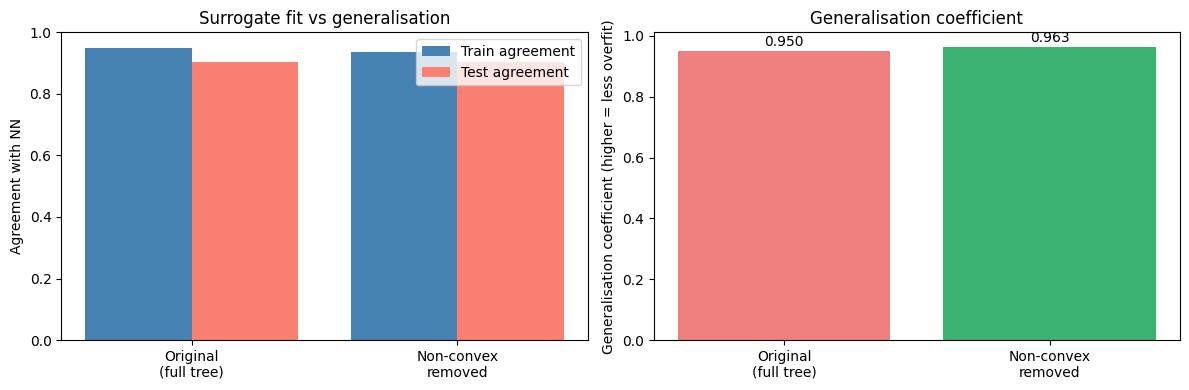

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Original\n(full tree)', 'Non-convex\nremoved']
x = np.arange(2)

axes[0].bar(x - 0.2, [b_tr, c_tr], 0.4, label='Train agreement', color='steelblue')
axes[0].bar(x + 0.2, [b_te, c_te], 0.4, label='Test agreement',  color='salmon')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Agreement with NN')
axes[0].set_title('Surrogate fit vs generalisation'); axes[0].legend()

axes[1].bar(x, [b_gc, c_gc], color=['lightcoral', 'mediumseagreen'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Generalisation coefficient (higher = less overfit)')
axes[1].set_title('Generalisation coefficient')
for i, v in enumerate([b_gc, c_gc]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


### Headline: the pruned surrogate vs the GRU

Same metric (true-label test / train) for both. If removal really cuts overfitting, the pruned surrogate's gen-coef should pass the GRU's.

Model                                 Train     Test   Gen-coef
----------------------------------------------------------------
MLP (network being explained)        0.9236   0.9148     0.9905
Simplex-tree surrogate               0.9008   0.8751     0.9715
----------------------------------------------------------------
Surrogate gen-coef 0.9715  vs  MLP gen-coef 0.9905  -> lower (NN already generalises well)
Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.


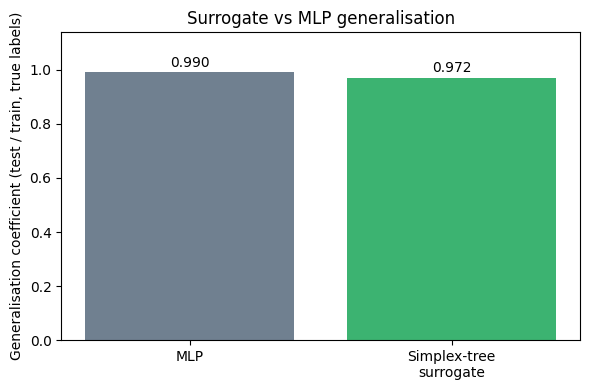

In [13]:
# Same metric (true-label test / train) for both. If pruning really cuts
# overfitting, the pruned surrogate's gen-coef should pass the MLP's.
nn_tr, nn_te, nn_gc = gen_coef(nn_pred, X_train, y_train, X_test, y_test)
p_tr,  p_te,  p_gc  = gen_coef(stc_convex.predict, X_train, y_train, X_test, y_test)

print(f'{"Model":34s} {"Train":>8s} {"Test":>8s} {"Gen-coef":>10s}')
print('-' * 64)
print(f'{"MLP (network being explained)":34s} {nn_tr:>8.4f} {nn_te:>8.4f} {nn_gc:>10.4f}')
print(f'{"Simplex-tree surrogate":34s} {p_tr:>8.4f} {p_te:>8.4f} {p_gc:>10.4f}')
print('-' * 64)
print(f'Surrogate gen-coef {p_gc:.4f}  vs  MLP gen-coef {nn_gc:.4f}  -> '
      f'{"HIGHER (the surrogate overfits less than the MLP)" if p_gc > nn_gc else "lower (NN already generalises well)"}')
print('Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy.')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['MLP', 'Simplex-tree\nsurrogate']
vals  = [nn_gc, p_gc]
bars = ax.bar(names, vals, color=['slategray', 'mediumseagreen'])
ax.set_ylabel('Generalisation coefficient (test / train, true labels)')
ax.set_title(f'Surrogate vs MLP generalisation')
ax.set_ylim(0, max(vals) * 1.15)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


### NN vs the convex surrogate at the *same* non-convex point

Counter-intuitive but exactly the point of the method: pick a point where the NN's decision boundary
**bends the wrong way** (a non-convex leaf). Step along the direction *LIME itself* says increases
$P(\text{target})$.

- **Left (NN, being explained):** LIME's own direction drives the NN **across the decision boundary** --
  $P(\text{target})$ drops below $0.5$ and the prediction leaves the target class (shaded band). LIME is
  locally **unfaithful** here.
- **Right (pruned convex surrogate), same point $x_0$:** along *its* LIME direction the surrogate **stays**
  in the target class -- $P(\text{target})$ never drops below $0.5$. LIME is **faithful**.

We search the non-convex pool for the clearest such point (NN drops below $0.5$; the surrogate agrees at
$x_0$ and never leaves the target class). If no such point exists it is reported honestly (no figure).
LIME's RNG is reset per call so the readout and plot agree.

In [ ]:
# NN vs the convex surrogate at the SAME non-convex point (self-contained).
import os
from paper_experiments_utils import (predict_proba, make_lime_explainer,
    push_along_lime, find_nonconvex_leaves, leaf_key_for_point)

if 'nn_proba' not in globals():
    def nn_proba(X_):
        return predict_proba(nn_model, X_, device=device)
if 'explainer' not in globals():
    explainer = make_lime_explainer(X_train, feature_names, n_classes=n_classes)
if 'ALPHA' not in globals():
    ALPHA = np.linspace(0, 0.4, 81)
EPSILON = globals().get('EPSILON', 0.05)

def _softmax(z):
    z = z - z.max(axis=1, keepdims=True); e = np.exp(z); return e / e.sum(axis=1, keepdims=True)

def stc_proba(X_):
    # Smooth probabilities for the pruned surrogate: softmax of its one-vs-rest
    # decision_function (so LIME can fit a meaningful local linear model).
    X_ = np.atleast_2d(np.asarray(X_, dtype=np.float64))
    d = np.asarray(stc_convex.classifier.decision_function(stc_convex.transform(X_)))
    if d.ndim == 1:
        d = np.column_stack([-d, d])
    return _softmax(d)

def push_model(point, proba_fn, target=None):
    # Step along the LIME 'increase P(target)' direction fit to proba_fn at point.
    # Resets LIME's RNG each call so the same point is reproducible across cells.
    point = np.asarray(point, dtype=np.float32)
    if target is None:
        target = int(np.argmax(proba_fn(point)[0]))
    explainer.random_state = np.random.RandomState(0)
    a, p_t, lime_t, w, d = push_along_lime(point, explainer, proba_fn,
        target_label=target, num_features=n_features, alphas=ALPHA)
    xs = np.clip(point + np.outer(ALPHA, d), 0, 1)
    return a, np.asarray(p_t), np.asarray(lime_t), target, np.argmax(proba_fn(xs), 1)

if 'depths' not in globals():
    depths = find_nonconvex_leaves(stc, epsilon=EPSILON)
_td = np.array([depths.get(leaf_key_for_point(stc, x), 0.0) for x in X_test])
_nz = float(np.median(_td[_td > 0])) if (_td > 0).any() else 0.0
_ncpool = np.where(_td >= _nz)[0] if _nz > 0 else np.arange(len(X_test))
print(f'non-convex pool: {len(_ncpool)}')

# Search for the clearest NN-crosses / surrogate-stays point.
_rng = np.random.default_rng(0)
_search = _ncpool if len(_ncpool) <= 120 else _rng.choice(_ncpool, 120, replace=False)
_best = None
for _i in _search:
    _x0 = X_test[int(_i)]
    _aN, _fN, _, _t, _amN = push_model(_x0, nn_proba)
    if (_amN == _t).all():
        continue                                    # NN argmax never leaves target -> not a demo
    _aS, _fS, _, _, _amS = push_model(_x0, stc_proba, target=_t)
    if not (_amS == _t).all():
        continue                                    # surrogate leaves target (or disagrees at x0) -> no contrast
    _score = (_fN[0] - _fN.min()) + _fS.min()       # deep NN drop + surrogate keeps P(target) high
    if _best is None or _score > _best[0]:
        _best = (_score, int(_i), int(_t))

demo2 = _best[1] if _best else None
if demo2 is None:
    print('No NN-crosses / surrogate-stays point found in the searched non-convex pool.')
else:
    print(f'NN-vs-surrogate demo point: test idx {demo2}  (target class {_best[2]})')
    x0 = X_test[demo2].astype(np.float32)
    target = int(np.argmax(nn_proba(x0[None])[0]))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    specs = [('NN (being explained)',      nn_proba,  axes[0]),
             ('Pruned convex surrogate',   stc_proba, axes[1])]
    summary = []
    for name, fn, ax in specs:
        a, f_t, g_t, tgt, am = push_model(x0, fn, target=target)
        crossed = bool((am != target).any())        # argmax leaves target (correct for multiclass)
        ax.plot(a, f_t, color='navy', lw=2, label=r'$P(\mathrm{target})$')
        off = np.asarray(am) != target
        if off.any():
            ax.fill_between(a, 0, 1, where=off, color='crimson', alpha=0.12,
                            transform=ax.get_xaxis_transform(), label='left target class')
        ax.axhline(0.5, color='gray', ls=':')
        ax.scatter([0], [f_t[0]], color='navy', zorder=5)
        ax.set_xlabel(r'step $\alpha$ along LIME direction'); ax.set_ylim(-0.02, 1.02)
        ax.set_title(f'{name}\n' + ('LIME points the wrong way -- crosses the boundary'
                                    if crossed else 'stays in the target class -- LIME faithful'))
        ax.legend(loc='best', fontsize=9)
        summary.append((name, float(f_t[0]), float(f_t.min()), crossed))
    axes[0].set_ylabel(r'$P(\mathrm{target\ class})$' + f'  (target = {target})')
    plt.suptitle(f'LIME at the SAME non-convex point $x_0$  (test idx {demo2})')
    plt.tight_layout(); plt.show()
    hdr = f'{"model":26s} {"start":>7s} {"min":>7s}   verdict'
    print(hdr); print('-' * len(hdr))
    for name, s, mn, cr in summary:
        print(f'{name:26s} {s:>7.3f} {mn:>7.3f}   '
              + ('CROSSES boundary (LIME unfaithful)' if cr else 'stays (LIME faithful)'))

non-convex pool: 439


No NN-crosses / surrogate-stays point found in the searched non-convex pool.
